In [2]:
import numpy as np
import matplotlib.pyplot as plt
import copy

import pyccl as ccl

from scipy.special import jv
from scipy.integrate import romb

import treecorr

In [3]:
ccl.spline_params.ELL_MIN_CORR = 1e1
ccl.spline_params.ELL_MAX_CORR = 1e7
print(ccl.spline_params.ELL_MIN_CORR)
print(ccl.spline_params.ELL_MAX_CORR)

10.0
10000000.0


In [4]:
from halo_model.power_spectra.matter_power import MatterPower
from halo_model.config.config import Config

from halo_model.halos.base.clump_mass_func.models.giocoli2010_mod import ClumpMassFuncGiocoli2010_mod
from halo_model.halos.base.concentration.models.neto2007 import ConcentrationNeto2007
from halo_model.halos.base.concentration.models.pieri2009_clumps import ConcentrationPieri2009_clumps

from halo_model.halos.base.mass_func.models.sheth1999 import MassFuncSheth1999
from halo_model.halos.base.profile.models.nfw import ProfileNFW
from halo_model.halos.base.bias.models.tinker2010 import BiasTinker2010
from halo_model.halos.base.r_vir.models.rho_m_delta import R_DeltaRho_m

from halo_model.power_spectra.Pm_computer import Pm_computer

In [26]:
#set config & create ccl cosmology object

cfg = Config()
cfg.beta = 0
# Cosmology parameters 

flat = True
H0 = 73.2
Om0 = 0.238
Ob0 = 0.0416
sigma8 = 0.759
ns = 0.958

cosmo = ccl.Cosmology(Omega_c = Om0, Omega_b=Ob0, h=0.01*H0, sigma8=0.759, n_s=ns)

In [28]:
#set profiles for power spectra

mass_func = MassFuncSheth1999()
smooth_profile = ProfileNFW(ConcentrationNeto2007(), R_DeltaRho_m(cfg.Delta_vir))
bias = BiasTinker2010(cfg.Delta_vir)
clump_mass_func = ClumpMassFuncGiocoli2010_mod(cfg.m0, beta=cfg.beta)
clump_profile = ProfileNFW(ConcentrationPieri2009_clumps(ConcentrationNeto2007(), d_vir=0.3), R_DeltaRho_m(cfg.Delta_vir))
clump_distribution = ProfileNFW(ConcentrationNeto2007(), R_DeltaRho_m(cfg.Delta_vir))

In [29]:
#computing model power spectra
z_grid = np.linspace(cfg.z_max, cfg.z_min, cfg.N_z) # from high redshift to low redshift so scale factor is monotonically increasing
k_grid = np.logspace(np.log10(cfg.k_min), np.log10(cfg.k_max), cfg.N_k)

Nz = len(z_grid)
Nk = len(k_grid)

P_grid = np.zeros((Nz, Nk))   # shape (z, k)

for i,z in enumerate(z_grid):
    cfg_local = copy.deepcopy(cfg)
    cfg_local.z = z
    
    clump_mass_func = ClumpMassFuncGiocoli2010_mod(cfg.m0, beta=0)

    Pm = MatterPower(cfg_local, 
                    mass_func=mass_func, 
                    smooth_profile=smooth_profile, 
                    bias=bias,
                    clump_mass_func=clump_mass_func, 
                    clump_profile=clump_profile, 
                    clump_distribution=clump_distribution)
    
    Pm_dict = Pm_computer(Pm, k_grid)
    Pm_tot = Pm_dict['P_tot']

    # cfg_local.beta = -0.01
    # clump_mass_func = ClumpMassFuncGiocoli2010_mod(cfg.m0, beta=cfg_local.beta)

    # Pm_mod = MatterPower(cfg_local, 
    #                 mass_func=mass_func, 
    #                 smooth_profile=smooth_profile, 
    #                 bias=bias,
    #                 clump_mass_func=clump_mass_func, 
    #                 clump_profile=clump_profile, 
    #                 clump_distribution=clump_distribution)
    
    # Pm_mod_dict = Pm_computer(Pm_mod, k_grid)
    # Pm_mod_tot = Pm_mod_dict['P_tot']

    P_grid[i, :] = Pm_tot #  - Pm_mod_tot


interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating f_sub function...
interpolating Ic and Jc functions...
interpolating f_sub function...
interpolating Ic and Jc functions...


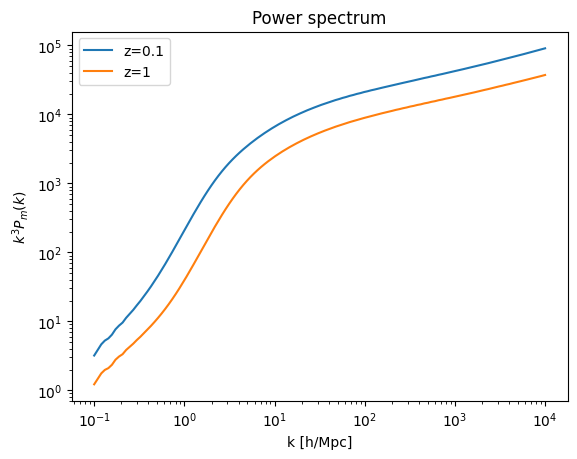

In [30]:
#plotting power spectra

a_grid = 1/(1+z_grid)
Pk = ccl.Pk2D(
    a_arr=a_grid,
    lk_arr=np.log(k_grid),
    pk_arr=P_grid,
    is_logp=False  
)

plt.plot(k_grid, k_grid**3 *Pk(k_grid, 1/(1 + 0.1)), label='z=0.1')
plt.plot(k_grid, k_grid**3 *Pk(k_grid, 1/(1 + 1)), label='z=1')

plt.legend()

plt.xlabel('k [h/Mpc]')
plt.ylabel(r'$k^3 P_m(k)$')

plt.title("Power spectrum")
plt.loglog()
plt.show()


In [31]:
# compute the Cls 

#first we make guassian source distribution
z = np.linspace(0, cfg.z_max, cfg.N_z)
nz = np.exp(-(z-0.8)**2 / (2*0.1**2))  # Gaussian around z=0.8
nz /= np.trapz(nz, z)  # normalize

# define shear tracers
tr = ccl.WeakLensingTracer(cosmo=cosmo, dndz=(z, nz))

# compute C_ell
ell = np.logspace(1, 6, 256 + 1)
cl = ccl.angular_cl(cosmo, tracer1=tr, tracer2=tr, ell=ell, p_of_k_a=Pk)



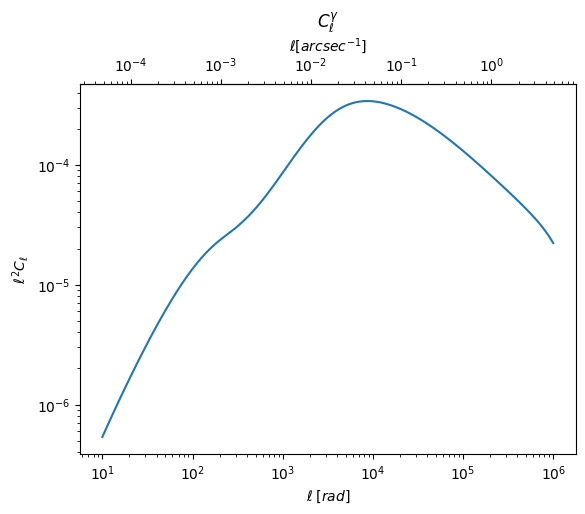

In [32]:
#plot the Cls

plt.plot(ell, ell**2*cl)

plt.title(r"$C_\ell^\gamma$")

plt.xlabel(r'$\ell \;[rad]$')
plt.ylabel(r'$\ell^2 C_\ell$')

def rad_to_arcsec_inv(x):
    return x / (180/np.pi * 3600)

def arcsec_to_rad_inv(x):
    return x / (np.pi/180 / 3600)

secax = plt.gca().secondary_xaxis('top', functions=(rad_to_arcsec_inv, arcsec_to_rad_inv))
secax.set_xlabel(r'$\ell [arcsec^{-1}]$')

plt.xscale('log')
plt.yscale("log")
plt.show()

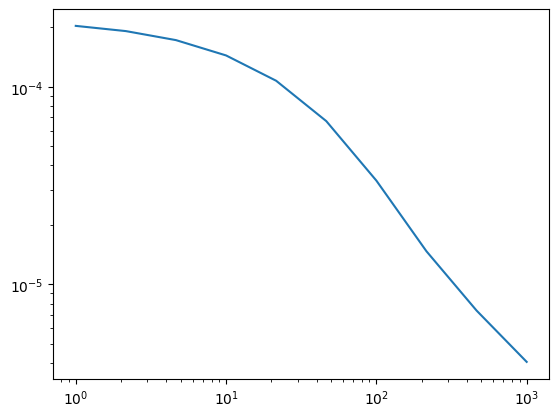

In [33]:
#compute xi_p, xi_m & set theta range

tmin = 1
tmax = 1e3

nthet = 10
theta_deg = np.geomspace(tmin/3600, tmax/3600, nthet)

xi_plus = ccl.correlation(cosmo, ell=ell, C_ell=cl, theta=theta_deg, type='GG+', method='FFTlog')
xi_minus = ccl.correlation(cosmo, ell=ell, C_ell=cl, theta=theta_deg, type='GG-', method='FFTlog')

xi_plus = ccl.correlation(cosmo, ell=ell, C_ell=cl, theta=theta_deg, type='GG+', method='bessel')
xi_minus = ccl.correlation(cosmo, ell=ell, C_ell=cl, theta=theta_deg, type='GG-', method='bessel')

plt.plot(theta_deg*3600, xi_plus)

plt.loglog()
plt.show()

In [34]:
#load in flagship sim data
from astropy.io import fits

# fits_file = fits.util.get_testdata_filepath("23586.fits")
hdul = fits.open("/home/milan/Desktop/thesis/flagship_sim/23778.fits")
hdr = hdul[1].header
data = hdul[1].data

z = data['true_redshift_gal']

# ra = data['ra_gal']
# dec = data['dec_gal']
# print(np.min(ra), np.max(ra))
# print(np.min(dec), np.max(dec))

#create mask in redshift:
z_min = 0.6
z_max = 1.2
#create mask in ra dec
# ra_min = 
mask = np.where((z > z_min) & (z < z_max))
z = z[mask]
# x = data['x_gal'][mask]
# y = data['y_gal'][mask]
# z = data['z_gal'][mask]

ra = data['ra_gal'][mask]
dec = data['dec_gal'][mask]

kappa = data['kappa'][mask]

gamma1 = data['gamma1'][mask]
gamma2 = data['gamma2'][mask]

eps1 = data['eps1_gal'][mask]
eps2 = data['eps2_gal'][mask]

In [35]:
#create theta bins
nbins = nthet

min_sep = 1/3600
max_sep = 1e3/3600

log_min = np.log10(min_sep)
log_max = np.log10(max_sep)
dlog = (log_max - log_min) / nbins

theta = theta_deg

In [36]:
#setup config for treecorr
config = {
    "nbins": nbins,
    "min_sep":  min_sep,
    "max_sep": max_sep,
    "sep_units": "degrees",
    "bin_type": "Log",

    # "min_rpar": PI_max,
    # "max_rpar": PI_max,

    "bin_slop": None,
    #"angle_slop": None,

    # "split_method": "mean", # How to split the cells in the tree when building the tree structure. 
    "metric": "Euclidean", #see metrics: https://rmjarvis.github.io/TreeCorr/_build/html/metric.html#metrics 
    "var_method": 'jackknife',
    "cross_patch_weight": 'match',
}

In [37]:
# def function that returns covariance

def get_cov(config, npatch, method='jackknife', including_shear=False):
    if including_shear:
        cat = treecorr.Catalog(
        ra=ra, dec=dec, ra_units='deg', dec_units='deg', k=kappa, g1=eps1 + gamma1, g2=eps2 +gamma2, npatch=npatch
        )
    else:
        cat = treecorr.Catalog(
        ra=ra, dec=dec, ra_units='deg', dec_units='deg', k=kappa, g1=eps1, g2=eps2, npatch=npatch
        )

    gg = treecorr.GGCorrelation(config)
    gg.process(cat)
    cov = gg.estimate_cov(method=method, cross_patch_weight='simple')

    return cov

def get_cov_delz(config, npatch, method='jackknife', including_shear=False, redshift_separation = 0):
    mask1 = (z < 0.9 - redshift_separation/2)
    mask2 = (z > 0.9 + redshift_separation/2)
    print(np.sum(mask1)/len(mask1))

    if including_shear:
        cat1 = treecorr.Catalog(
            ra=ra[mask1], dec=dec[mask1], ra_units='deg', dec_units='deg', 
            k=kappa[mask1], g1=eps1[mask1] + gamma1[mask1], g2=eps2[mask1] +gamma2[mask1], npatch=npatch
        )

        cat2 = treecorr.Catalog(
            ra=ra[mask2], dec=dec[mask2], ra_units='deg', dec_units='deg', 
            k=kappa[mask2], g1=eps1[mask2] + gamma1[mask2], g2=eps2[mask2] +gamma2[mask2], npatch=npatch
        )

    else:
        cat1 = treecorr.Catalog(
            ra=ra[mask1], dec=dec[mask1], ra_units='deg', dec_units='deg', 
            k=kappa[mask1], g1=eps1[mask1], g2=eps2[mask1], npatch=npatch
        )

        cat2 = treecorr.Catalog(
            ra=ra[mask2], dec=dec[mask2], ra_units='deg', dec_units='deg', 
            k=kappa[mask2], g1=eps1[mask2], g2=eps2[mask2], npatch=npatch
        )

    gg = treecorr.GGCorrelation(config)
    gg.process(cat1, cat2)
    cov = gg.estimate_cov(method=method, cross_patch_weight='simple')

    return cov

In [16]:
# compute covariance for IA and GLIA

npatch = 30
redshift_separation = 0.1

# IA_cov = get_cov(config, npatch=npatch, including_shear=False)  #divide by 150 since 10 by 10 degrees is 1/150th of the half sky
# GLIA_cov = get_cov(config, npatch=npatch, including_shear=True) 

IA_cov = get_cov_delz(config, npatch=npatch, including_shear=False, redshift_separation=redshift_separation)  #divide by 150 since 10 by 10 degrees is 1/150th of the half sky
GLIA_cov = get_cov_delz(config, npatch=npatch, including_shear=True, redshift_separation=redshift_separation) 

0.37286019943236137
0.37286019943236137


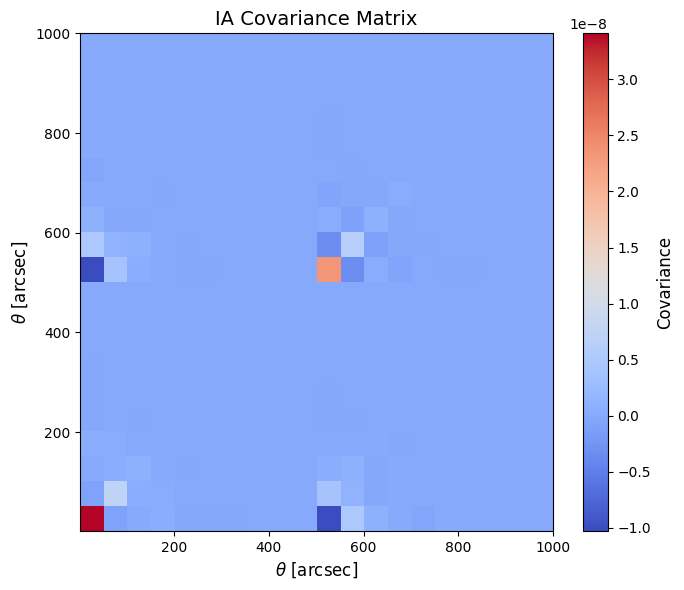

In [17]:
# plot cov for IA

plt.figure(figsize=(7,6))
theta_as = 3600 * theta
extent = [theta_as[0], theta_as[-1], theta_as[0], theta_as[-1]] 

im = plt.imshow(
    IA_cov,
    origin='lower',
    cmap='coolwarm',
    aspect='auto',
    extent=extent
)

# plt.xscale("log")
# plt.yscale("log")

cbar = plt.colorbar(im)
cbar.set_label("Covariance", fontsize=12)

plt.title("IA Covariance Matrix", fontsize=14)
plt.xlabel(r"$\theta$ [arcsec]", fontsize=12)
plt.ylabel(r"$\theta$ [arcsec]", fontsize=12)

plt.tight_layout()
plt.show()

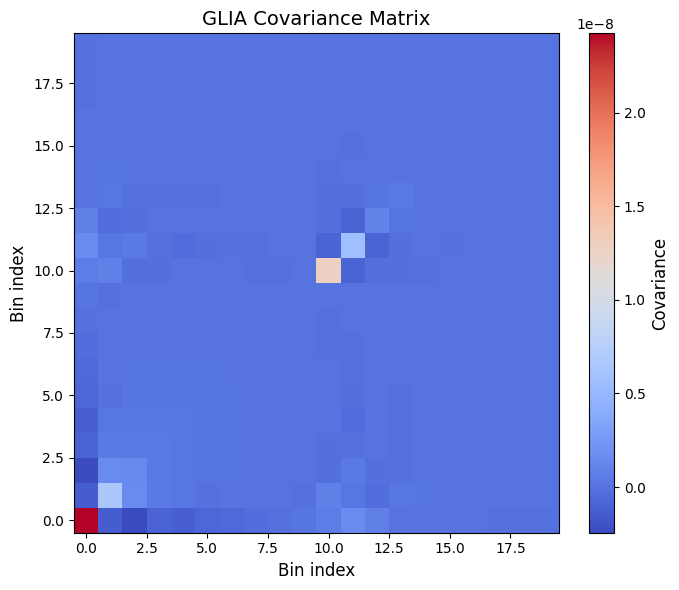

In [18]:
# plot cov for GLIA

plt.figure(figsize=(7,6))

im = plt.imshow(
    GLIA_cov,
    origin='lower',
    cmap='coolwarm',
    aspect='auto'
)

cbar = plt.colorbar(im)
cbar.set_label('Covariance', fontsize=12)

plt.title('GLIA Covariance Matrix', fontsize=14)
plt.xlabel('Bin index', fontsize=12)
plt.ylabel('Bin index', fontsize=12)

plt.tight_layout()
plt.show()

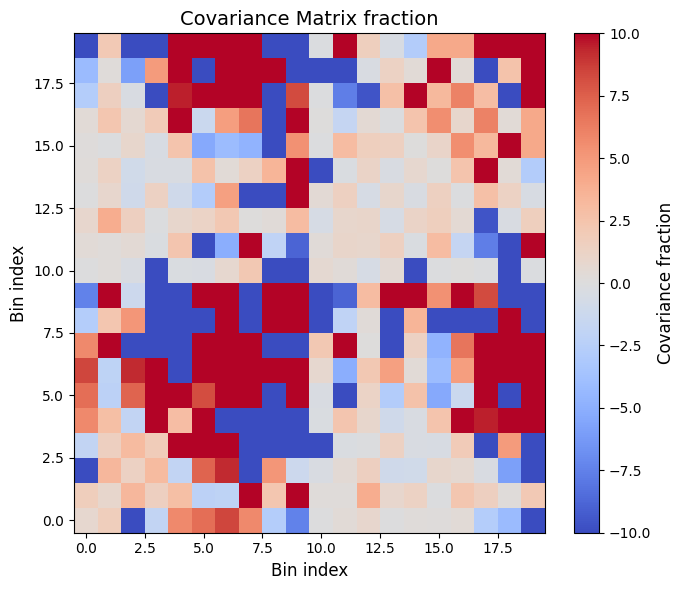

In [19]:
# plot fraction of covariances GLIA/IA

cov_fraction = GLIA_cov/IA_cov

plt.figure(figsize=(7,6))

im = plt.imshow(
    cov_fraction,
    origin='lower',
    cmap='coolwarm',
    aspect='auto',
    vmin=-10,
    vmax=10
)

cbar = plt.colorbar(im)
cbar.set_label('Covariance fraction', fontsize=12)

plt.title('Covariance Matrix fraction', fontsize=14)
plt.xlabel('Bin index', fontsize=12)
plt.ylabel('Bin index', fontsize=12)

plt.tight_layout()
plt.show()

0.6431516978474026
0.445409006643948
0.4173730869613993
0.37286019943236137


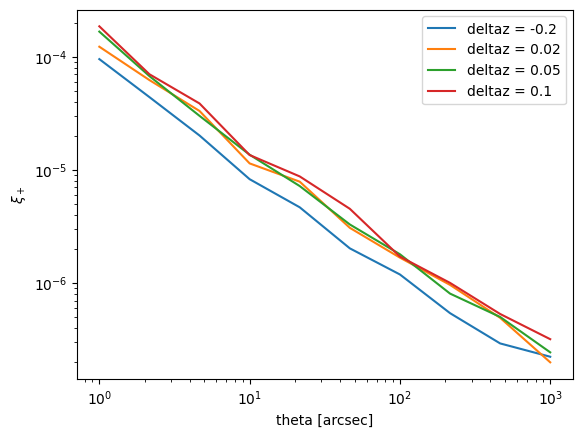

In [20]:
# plot diagonal of covariance versus theta for various redshift_separations

for deltaz in [-0.2, 0.02, 0.05, 0.1]:
    IA_cov = get_cov_delz(config, npatch=npatch, including_shear=False, redshift_separation=deltaz)  #divide by 150 since 10 by 10 degrees is 1/150th of the half sky
    # GLIA_cov = get_cov_delz(config, npatch=npatch, including_shear=True, redshift_separation=deltaz) 

    diag_IA_xip = np.diag(IA_cov)[:nbins]
    # diag_GLIA_xip = np.diag(GLIA_cov)[:nbins]

    diag_IA_xim = np.diag(IA_cov)[nbins:]
    # diag_GLIA_xim = np.diag(GLIA_cov)[nbins:]

    plt.plot(theta_as, np.sqrt(diag_IA_xip), label=f'deltaz = {deltaz}')
    # plt.plot(theta_as, np.sqrt(diag_GLIA_xip), label='GLIA_xip')
    # plt.plot(theta_as, np.sqrt(diag_IA_xim), label='IA_xim')
    # plt.plot(theta_as, np.sqrt(diag_GLIA_xim), label='GLIA_xim')

# plt.plot(theta_deg*3600, xi_plus, label=r'$C^\gamma_\ell$')

plt.legend()
plt.loglog()

plt.xlabel('theta [arcsec]')
plt.ylabel(r'$\xi_+$')
plt.show()



0.4173730869613993


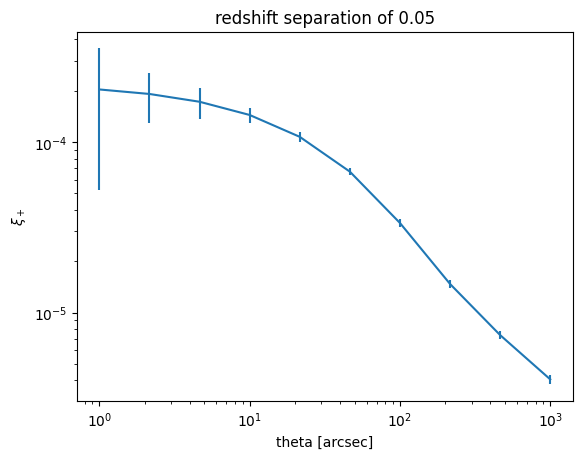

In [38]:
redshift_separation = 0.05

IA_cov_delz = get_cov_delz(config, npatch=npatch, including_shear=False, redshift_separation=redshift_separation)
diag_IA_xip_delz = np.diag(IA_cov_delz)[:nbins]

plt.errorbar(theta_deg*3600, xi_plus, np.sqrt(diag_IA_xip_delz))

plt.loglog()
plt.xlabel('theta [arcsec]')
plt.ylabel(r'$\xi_+$')
plt.title(f'redshift separation of {redshift_separation}')
plt.show()

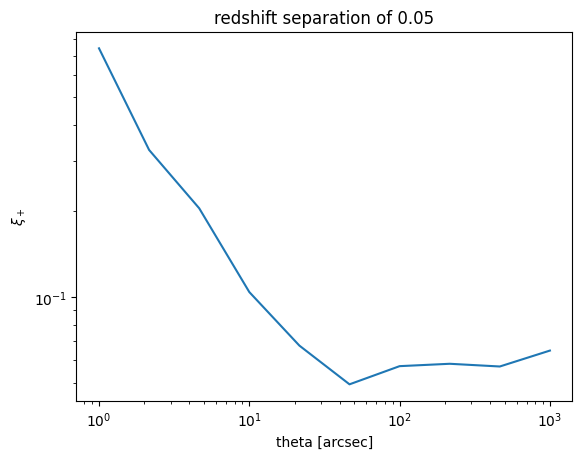

In [39]:
plt.plot(theta_deg*3600, np.sqrt(diag_IA_xip_delz)/xi_plus)

plt.loglog()
plt.xlabel('theta [arcsec]')
plt.ylabel(r'$\xi_+$')
plt.title(f'redshift separation of {redshift_separation}')
plt.show()

In [22]:
# def function that returns SNR for given theta max

def SNR_theta_max(theta_max, factor=1):
    theta_mask = theta_deg <= theta_max
    data_vec = np.concatenate((xi_plus[theta_mask], xi_minus[theta_mask]))

    # chopping the covariance matrix
    idx  =np.concatenate((theta_mask, theta_mask))
    _IA_cov = np.delete(IA_cov, ~idx, axis=0)
    _IA_cov = np.delete(_IA_cov, ~idx, axis=1)

    cov_inv = factor*np.linalg.inv(_IA_cov) # taking into account that sample is 10x10 deg while euclid surveys half sky
    return np.sqrt(data_vec @ cov_inv @ data_vec.T)

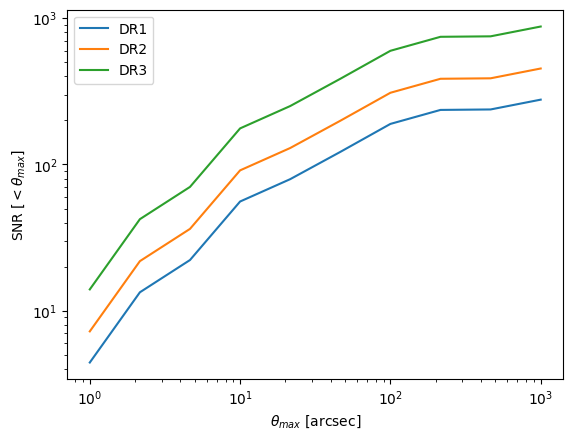

In [23]:
# compute SNR values for various surveys at various theta max

SNR_vals_DR1 = [SNR_theta_max(temp, factor=15) for temp in theta_deg]
SNR_vals_DR2 = [SNR_theta_max(temp, factor=40) for temp in theta_deg]
SNR_vals_DR3 = [SNR_theta_max(temp, factor=150) for temp in theta_deg]


plt.plot(theta_deg * 3600, SNR_vals_DR1, label='DR1')
plt.plot(theta_deg * 3600, SNR_vals_DR2, label='DR2')
plt.plot(theta_deg * 3600, SNR_vals_DR3, label='DR3')

plt.legend()

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$\theta_{max}$ [arcsec]')
plt.ylabel(r'SNR $[<\theta_{max}]$')

plt.show()